# Noise-distribution robustness

Produces Figure 4.

In [1]:
import sys
sys.path.insert(0, "..")   # make src importable from the repository root

from src.utils import load_results

results = load_results("noise_distribution_robustness")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from src.figstyle import (CATEGORICAL, DASHES, PALETTE, PT, figure,
                          panel_label, save_figure,
                          threshold_line, use_manuscript_style)

use_manuscript_style()


Wrote figures/fig4_noise_distribution_robustness.pdf


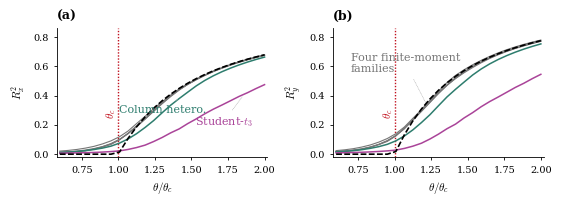

the finite-moment families spread by at most 0.0245, against a trial SD of 0.0528 (ratio 0.46)
supercritical MAE: gaussian=0.0083, t5=0.0068, t4.5=0.0056, t3=0.2390, laplace=0.0047, heteroskedastic=0.0464


In [3]:
FLAT = ('gaussian', 't5', 't4.5', 'laplace')
DEVIANT = {'heteroskedastic': CATEGORICAL[0], 't3': CATEGORICAL[1]}
YLIM = (-0.02, 0.86)

theta_vals = np.asarray(results['theta_values'])
tn = theta_vals / results['theta_c']

def mean_of(noise_type, key):
    return np.asarray([r[f'{key}_mean'] for r in results['noise'][noise_type]])

fig, axes = figure(140.0, 2)
for ax, key, theory_key, ylabel in ((axes[0], 'Rx2_pls', 'theory_Rx2', r'$R_x^2$'),
                                    (axes[1], 'Ry2_pls', 'theory_Ry2', r'$R_y^2$')):
    for nt in FLAT:
        ax.plot(tn, mean_of(nt, key), '-', lw=0.8, color=PALETTE['grouped'],
                zorder=3)
    for nt, col in DEVIANT.items():
        ax.plot(tn, mean_of(nt, key), '-', lw=1.1, color=col, zorder=4)
    ax.plot(tn, results[theory_key], color=PALETTE['theory'], lw=1.2,
            ls=DASHES['theory_alt'], zorder=5)
    threshold_line(ax, 1.0, r'$\theta_c$', y=0.34)
    ax.set_xlabel(r'$\theta/\theta_c$')
    ax.set_ylabel(ylabel)
    ax.set_xlim(tn.min() - 0.02, tn.max() + 0.02)
    ax.set_ylim(*YLIM)

def lead(ax, text, color, anchor, xy_text, ha='center'):
    ax.annotate(text, anchor, xytext=xy_text, textcoords='data',
                fontsize=PT['annot'], color=color, ha=ha, va='center',
                zorder=9,
                arrowprops=dict(arrowstyle='-', lw=0.45, color='#B5B5B5',
                                linestyle=(0, (1, 1.5)), shrinkA=2, shrinkB=2))

ax = axes[0]
het = mean_of('heteroskedastic', 'Rx2_pls')
lead(ax, 'Column hetero.', DEVIANT['heteroskedastic'],
     (1.42, float(np.interp(1.42, tn, het))), (1.30, 0.30))
t3 = mean_of('t3', 'Rx2_pls')
lead(ax, r'Student-$t_3$', DEVIANT['t3'],
     (1.86, float(np.interp(1.86, tn, t3))), (1.72, 0.22))

grouped_y = np.mean([mean_of(nt, 'Ry2_pls') for nt in FLAT], axis=0)
lead(axes[1], 'Four finite-moment\nfamilies', PALETTE['grouped'],
     (1.22, float(np.interp(1.22, tn, grouped_y))), (0.70, 0.62), ha='left')

panel_label(axes[0], '(a)')
panel_label(axes[1], '(b)')
save_figure(fig, 'fig4_noise_distribution_robustness')
plt.show()

spread = np.max(np.ptp([mean_of(nt, 'Rx2_pls') for nt in FLAT], axis=0))
sd = np.median([[r['Rx2_pls_std'] for r in results['noise'][nt]] for nt in FLAT])
print(f'the finite-moment families spread by at most {spread:.4f}, '
      f'against a trial SD of {sd:.4f} (ratio {spread / sd:.2f})')
print('supercritical MAE: ' + ', '.join(
    f'{k}={v:.4f}' for k, v in results['mae_supercritical'].items()))
